# 05 — ML Model & SHAP Interpretability
Predict order-line profitability (profitable vs. not) with Random Forest and XGBoost, compare them, and use SHAP to explain what drives profit — then translate that into business language.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)
from xgboost import XGBClassifier
import shap

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

df = pd.read_csv('../data/processed/superstore_clean.csv', parse_dates=['order_date'])
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sales,quantity,discount,profit,order_year,order_month,order_year_month,order_quarter,profit_margin,fulfillment_days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2,0.00,41.9136,2016,11,2016-11,2016Q4,0.1600,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,3,0.00,219.5820,2016,11,2016-11,2016Q4,0.3000,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2,0.00,6.8714,2016,6,2016-06,2016Q2,0.4700,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5,0.45,-383.0310,2015,10,2015-10,2015Q4,-0.4000,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2,0.20,2.5164,2015,10,2015-10,2015Q4,0.1125,7


## 1. Define the target
Target: whether an order **line** is profitable (`profit > 0`). This is a per-line-item classification, not per-order — deliberately, so each row is one modeling example.

In [2]:
df['is_profitable'] = (df['profit'] > 0).astype(int)
df['is_profitable'].value_counts(normalize=True)

is_profitable
1    0.806284
0    0.193716
Name: proportion, dtype: float64

## 2. Feature selection (avoiding leakage)
`profit` and `profit_margin` are dropped since they are derived directly from the target — including them would leak the answer. We keep only features that would be known *before* the order's outcome is observed.

In [3]:
feature_cols = ['sales', 'quantity', 'discount', 'category', 'sub_category',
                 'segment', 'region', 'ship_mode', 'order_month']
feature_cols = [c for c in feature_cols if c in df.columns]

model_df = df[feature_cols + ['is_profitable']].dropna()

cat_cols = model_df[feature_cols].select_dtypes(include='object').columns.tolist()
num_cols = [c for c in feature_cols if c not in cat_cols]
print("Categorical:", cat_cols)
print("Numeric:", num_cols)

Categorical: ['category', 'sub_category', 'segment', 'region', 'ship_mode']
Numeric: ['sales', 'quantity', 'discount', 'order_month']


In [4]:
encoders = {}
X = model_df[feature_cols].copy()
for c in cat_cols:
    le = LabelEncoder()
    X[c] = le.fit_transform(X[c])
    encoders[c] = le

y = model_df['is_profitable']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (7995, 9), Test: (1999, 9)


## 3. Random Forest

In [5]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=5,
    random_state=RANDOM_SEED, n_jobs=-1
)
rf.fit(X_train, y_train)

cv_scores = cross_val_score(
    rf, X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED), scoring='roc_auc'
)
print(f"RF 5-fold CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

RF 5-fold CV ROC-AUC: 0.9799 (+/- 0.0046)


## 4. XGBoost

In [6]:
xgb = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_SEED, eval_metric='logloss'
)
xgb.fit(X_train, y_train)

cv_scores_xgb = cross_val_score(
    xgb, X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED), scoring='roc_auc'
)
print(f"XGB 5-fold CV ROC-AUC: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std():.4f})")

xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

XGB 5-fold CV ROC-AUC: 0.9824 (+/- 0.0030)


## 5. Model comparison

In [7]:
def eval_model(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
    }

comparison = pd.DataFrame([
    eval_model('Random Forest', y_test, rf_pred, rf_proba),
    eval_model('XGBoost', y_test, xgb_pred, xgb_proba),
]).set_index('Model').round(4)
comparison

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Random Forest,0.9455,0.9434,0.9919,0.9670,0.9837
XGBoost,0.9465,0.9552,0.9795,0.9672,0.9868


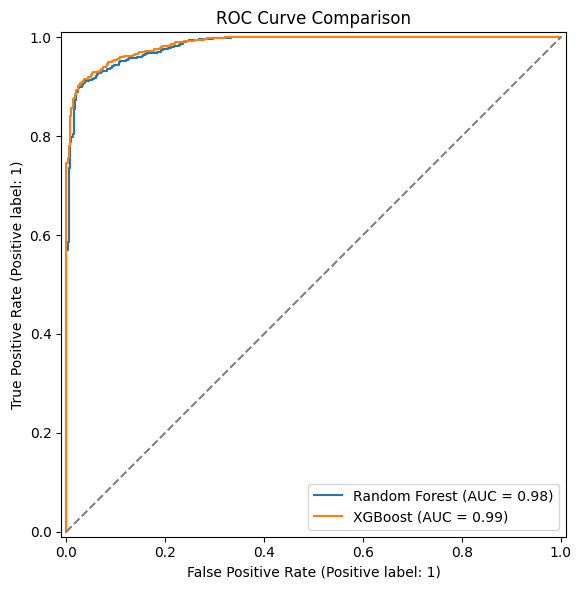

Best model by ROC-AUC: XGBoost


In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, rf_proba, name='Random Forest', ax=ax)
RocCurveDisplay.from_predictions(y_test, xgb_proba, name='XGBoost', ax=ax)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve Comparison')
plt.tight_layout()
plt.savefig('../reports/figures/roc_comparison.png', dpi=150)
plt.show()

best_model_name = comparison['ROC-AUC'].idxmax()
best_model = rf if best_model_name == 'Random Forest' else xgb
print(f"Best model by ROC-AUC: {best_model_name}")

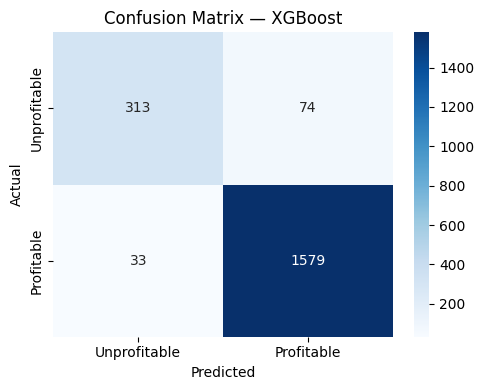

              precision    recall  f1-score   support

Unprofitable       0.90      0.81      0.85       387
  Profitable       0.96      0.98      0.97      1612

    accuracy                           0.95      1999
   macro avg       0.93      0.89      0.91      1999
weighted avg       0.95      0.95      0.95      1999



In [9]:
cm = confusion_matrix(y_test, best_model.predict(X_test))
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Unprofitable', 'Profitable'], yticklabels=['Unprofitable', 'Profitable'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_test, best_model.predict(X_test), target_names=['Unprofitable', 'Profitable']))

## 6. SHAP interpretability

In [10]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# For RF's predict_proba-based classifier, shap_values may be a list [class0, class1]
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

C:\Users\Aagam Shah\AppData\Local\Temp\ipykernel_23424\2594153143.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_test, feature_names=feature_cols, show=False)


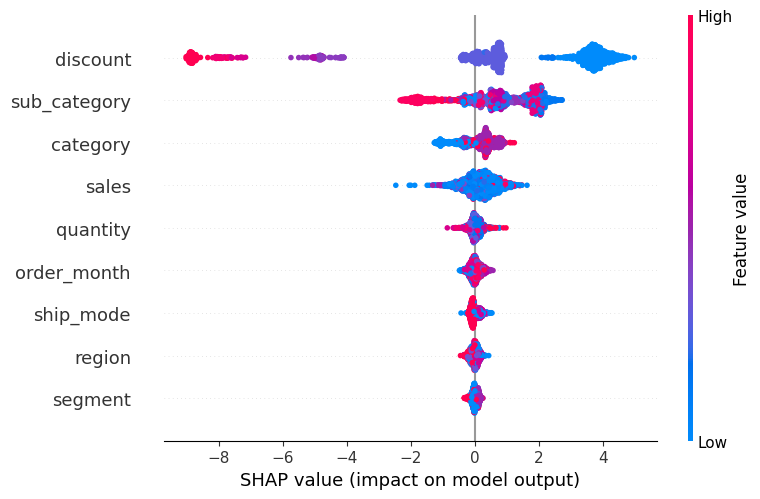

In [11]:
shap.summary_plot(sv, X_test, feature_names=feature_cols, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

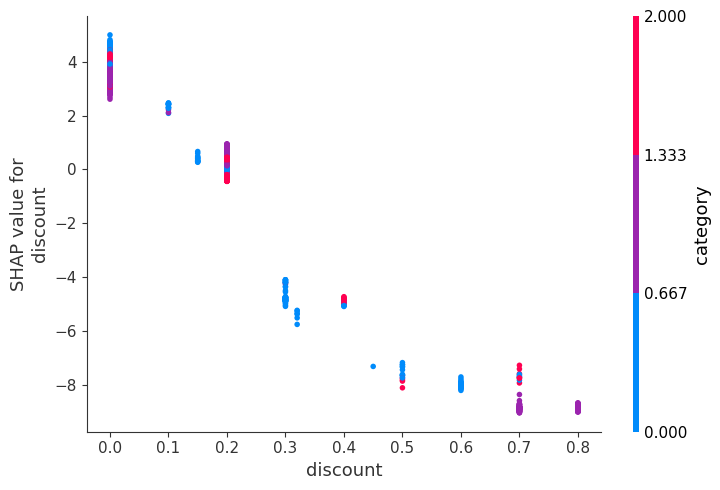

In [12]:
shap.dependence_plot('discount', sv, X_test, feature_names=feature_cols, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_discount_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

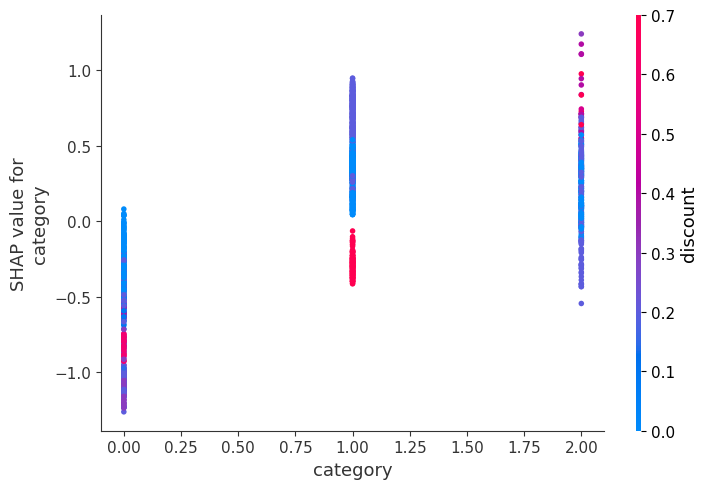

In [13]:
if 'category' in feature_cols:
    shap.dependence_plot('category', sv, X_test, feature_names=feature_cols, show=False)
    plt.tight_layout()
    plt.savefig('../reports/figures/shap_category_dependence.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Feature importance summary (business language)

In [14]:
mean_abs_shap = pd.Series(np.abs(sv).mean(axis=0), index=feature_cols).sort_values(ascending=False)
print("Feature impact ranking (mean |SHAP value|):")
print(mean_abs_shap)

top_feature = mean_abs_shap.index[0]
print(f"\nThe single strongest driver of order profitability is: {top_feature}")

Feature impact ranking (mean |SHAP value|):
discount        3.040637
sub_category    1.215939
category        0.450238
sales           0.408276
quantity        0.130974
order_month     0.124923
ship_mode       0.108377
region          0.096014
segment         0.074393
dtype: float32

The single strongest driver of order profitability is: discount


## Summary
Fill in with the printed values once run end to end:
- Best model: **{best_model_name}**, ROC-AUC **{comparison.loc[best_model_name, 'ROC-AUC']}**
- Top SHAP driver of profitability: **{top_feature}**
- Translate the discount dependence plot into a business rule, e.g. "discounts above X% are strongly associated with unprofitable order lines" using the actual threshold observed in the plot.